In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm

Transmonin diagonalisaatio

In [2]:
# Fysikaalisten vakioiden määrittely

phi_zero = 2.0678e-15 #Magneettivuon kvantti
hbar = 1.055e-34 #redusoitu Planckin vakio  

In [3]:
class Transmon:

    def __init__(self,E_C,E_J,N):

        self.E_C=E_C
        self.E_J=E_J
        self.N=N   

        self.phi = np.linspace(-np.pi, np.pi, N, endpoint=False) #vaiheoperaattori diskretisoituna välillä [-pi,pi] 1000 pisteeseen
        self.delta_phi = self.phi[2]-self.phi[1] #vaiheoperaattorin diskresitoitu askelväli

        M = np.eye(N,k=1)+np.eye(N,k=-1)-2*np.eye(N) #Muodostetaan numero-operaattorin neliön matriisiesitys differenssimenetelmällä
        M[0,-1]=1
        M[-1,0]=1
        n_squared = -M/(self.delta_phi**2)

        self.H_0 = 4*E_C*n_squared-E_J*np.diag(np.cos(self.phi)) #Hamiltonin operaattori

        energies, eigenstates = np.linalg.eigh(self.H_0) # Transmonin ominaisenergiat ja -tilat

        self.energies = energies
        self.eigenstates = eigenstates
        self.frequency = energies[1]-energies[0]

    def H_D_phibasis(self,A,f_1,f_2): #Ajettu Hamiltonin operaattori phi-kannassa (n_g:n muutos)

        M=np.eye(self.N,k=1)-np.eye(self.N,k=-1)
        M[0,-1]=1
        M[-1,0]=-1

        def n_g(t): return (A/(8*self.E_C)) * (np.cos(f_1 * t)-np.cos(f_2 * t))
        def offset_term(t): return 1j * n_g(t) * M / self.delta_phi
        def H_t(t): return self.H_0 + 4 * self.E_C * offset_term(t)

        return H_t
    
    def H_D_eigbasis(self,A,f_1,f_2,dim): #Ajettu Hamiltonin operaattori ominaiskannassa
 
        H_0 = np.diag(self.energies[0:dim]-self.energies[0])

        M = np.zeros((dim, dim))
        vals = np.sqrt(np.arange(1, dim))
        M[np.arange(dim-1), np.arange(1, dim)] = vals      
        M[np.arange(1, dim), np.arange(dim-1)] = vals

        def H_t(t): return H_0 + A*(np.cos(f_1*t)-np.cos(f_2*t))*M

        return H_t
    

class time_evolution:

    def __init__(self,generator):
        self.generator = generator
    
    def U(self, t, dt): return expm(-1j * self.generator(t) * dt) #Aikaevoluutio-operaattori

    def U_floquet(self, period, N): #Floquet-operaattori

        t_vals_floquet=np.linspace(0,period,N)
        delta_t_floquet = t_vals_floquet[1]-t_vals_floquet[0]

        U_f = self.U(0, 0)
        for i in range(1, N): #Aikakehitysoperaattori yhdelle Floquet-jaksolle
            U_f = self.U(t_vals_floquet[i-1]+delta_t_floquet/2, delta_t_floquet) @ U_f
        return U_f

Transmonin määrittely

In [4]:
E_C = 0.3 #Varausenergia (GHz)
E_J = 8 #Josephsonin energia (GHz)

qubit=Transmon(E_C,E_J,1000)

In [5]:
print("Transmonin seitsemän ensimmäistä energiatasoa (GHz), kun E_0=0")
print(qubit.energies[0:7]-qubit.energies[0])

Transmonin seitsemän ensimmäistä energiatasoa (GHz), kun E_0=0
[ 0.          4.05672712  7.73043296 11.07460509 13.12340606 17.41564073
 17.57885855]


Schrödingerin yhtälön numeerinen ratkaisu kahden taajuuden ajossa

In [ ]:
T_q = 2*np.pi/qubit.frequency
f_1 = qubit.frequency*1.2 #Ajotaajuudet
f_2 = qubit.frequency*1.4

N  = 2000
dim  = 7

#alpha=qubit.energies[2]-2*qubit.energies[1]+qubit.energies[0]
#eta=A*(qubit.frequency-alpha)/((f_d**2-(qubit.frequency-alpha)**2)*2)

In [7]:
def find_params_eigenbasis(q, A, K, N, dim):
    excited_max=[] #e-tason suurin itseisarvo aikakehityksen aikana

    min_range = 94000
    max_range = 100000

    scale = 100000

    for i in range(min_range,max_range):

        f_1_shifted=f_1*i/scale
        f_2_shifted=f_2*i/scale

        T_floquet= np.pi*2/(qubit.frequency*0.2*i/scale)

        evolution=time_evolution(q.H_D_eigbasis(A,f_1_shifted,f_2_shifted,dim))
        U_floquet=evolution.U_floquet(T_floquet,N)

        psi = np.zeros((K, dim), dtype=complex) #Alustetaan kubitin tila perustilaan
        psi[0,0] = 1

        for j in range(1, K): #Aikakehitys
            psi[j] = U_floquet @ psi[j-1]

        excited_max.append(max(np.abs(psi[:, 1])))

    c=(np.argmax(excited_max)+min_range)/scale

    f_1_shifted=f_1*c
    f_2_shifted=f_2*c

    delta=qubit.frequency-2*f_1_shifted+f_2_shifted

    T_floquet= np.pi*2/(qubit.frequency*0.2*c)

    evolution=time_evolution(qubit.H_D_eigbasis(A,f_1_shifted,f_2_shifted,dim))
    U_floquet=evolution.U_floquet(T_floquet,N)

    psi = np.zeros((K*100, dim), dtype=complex) #Alustetaan kubitin tila perustilaan
    psi[0,0] = 1

    for i in range(1, K*100): #Aikakehitys
        psi[i] = U_floquet @ psi[i-1]

    prob_g = np.abs(psi[:, 1])**2
    prob_e = np.abs(psi[:, 1])**2
    prob_f = np.abs(psi[:, 2])**2
    max_vals=np.array([max(prob_g),max(prob_e),max(prob_f)]) #Suurimmat tasojen todennäköisyydet

    prob_g_offset = prob_g-np.mean(prob_g)
    fft_vals = np.fft.rfft(prob_g_offset)
    freqs = np.fft.rfftfreq(len(prob_g_offset), d=T_floquet)

    magnitude = np.abs(fft_vals)
    magnitude[0] = 0

    frequency=freqs[np.argmax(magnitude)]

    return[delta,frequency,max_vals,c]

In [8]:
deltas = []
rabis = []
max_vals = []
c_vals = []

K = 4000

for i in range (5,25):
    A = qubit.frequency*(i/100)
    params=find_params_eigenbasis(qubit, A, K, N, dim)
    deltas.append(params[0])
    rabis.append(params[1])
    max_vals.append(params[2])
    c_vals.append(params[3])
    print(i)

5


6


7


8


9


...

20


21


22


23


24


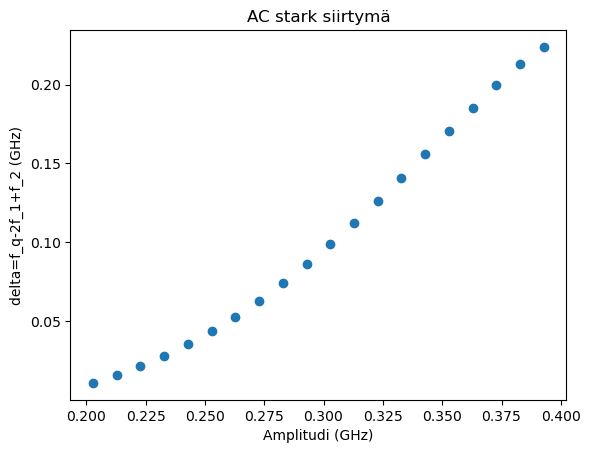

[np.float64(0.010790894133881679), np.float64(0.01553726486194229), np.float64(0.021216682827142286), np.float64(0.027748013487123302), np.float64(0.03521239138424548), np.float64(0.043569249247326525), np.float64(0.052859154347546955), np.float64(0.0630009721425493), np.float64(0.0740352699035105), np.float64(0.08600261490161198), np.float64(0.09870017078095383), np.float64(0.11204680299917502), np.float64(0.12636704972571788), np.float64(0.14076843099462), np.float64(0.1561028595006615), np.float64(0.170666509854283), np.float64(0.18494618930964624), np.float64(0.1999966469174268), np.float64(0.21305930823738883), np.float64(0.22393133691363065)]
[np.float64(0.99734), np.float64(0.99617), np.float64(0.99477), np.float64(0.99316), np.float64(0.99132), np.float64(0.98926), np.float64(0.98697), np.float64(0.98447), np.float64(0.98175), np.float64(0.9788), np.float64(0.97567), np.float64(0.97238), np.float64(0.96885), np.float64(0.9653), np.float64(0.96152), np.float64(0.95793), np.float

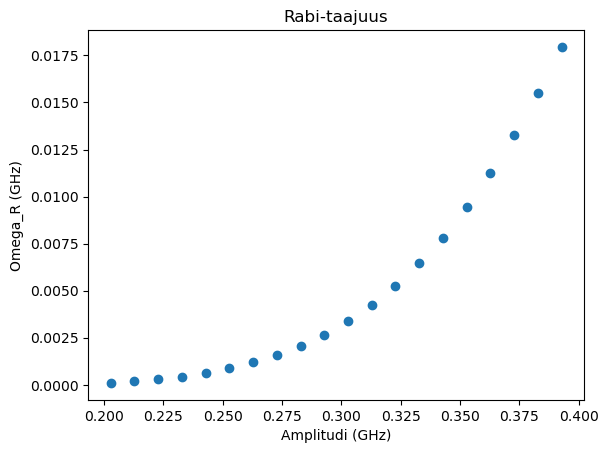

[np.float64(0.00010238498916460717), np.float64(0.00017912433249630007), np.float64(0.00028741646656140634), np.float64(0.00043603771926614384), np.float64(0.0006307633102196989), np.float64(0.0008817445558200026), np.float64(0.0011976838927680441), np.float64(0.001593184681845159), np.float64(0.0020793944422987432), np.float64(0.0026684529254893843), np.float64(0.003382775402514761), np.float64(0.004238067662271434), np.float64(0.005248248994844322), np.float64(0.006448395928862721), np.float64(0.00782181535992771), np.float64(0.009432835491485343), np.float64(0.011259445276618232), np.float64(0.013265214717659), np.float64(0.015506047497380795), np.float64(0.017951022026845925)]


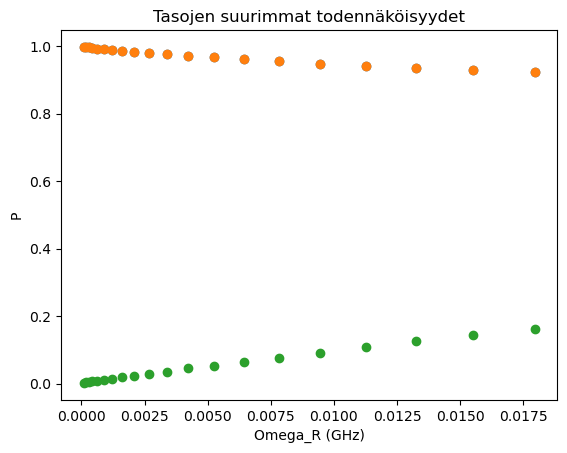

In [9]:
A_vals=np.arange(20)*0.01+qubit.frequency*0.05

plt.figure()
plt.plot(A_vals, deltas, 'o')
plt.xlabel("Amplitudi (GHz)")
plt.ylabel("delta=f_q-2f_1+f_2 (GHz)")
plt.title("AC stark siirtymä")
plt.show()
print(deltas)
print(c_vals)

plt.figure()
plt.plot(A_vals, rabis, 'o')
plt.xlabel("Amplitudi (GHz)")
plt.ylabel("Omega_R (GHz)")
plt.title("Rabi-taajuus")
plt.show()
print(rabis)

g_vals=[arr[0] for arr in max_vals]
e_vals=[arr[1] for arr in max_vals]
f_vals=[arr[2] for arr in max_vals]

plt.figure()
plt.plot(rabis, g_vals, 'o')
plt.plot(rabis, e_vals, 'o')
plt.plot(rabis, f_vals, 'o')
plt.xlabel("Omega_R (GHz)")
plt.ylabel("P")
plt.title("Tasojen suurimmat todennäköisyydet")
plt.show()

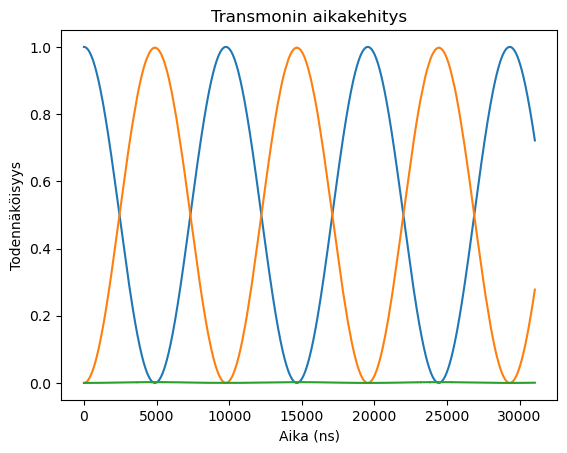

In [10]:
A=0.05*qubit.frequency

K=4000

c=0.99734

f_1_shifted=f_1*c
f_2_shifted=f_2*c

T_floquet= np.pi*2/(qubit.frequency*0.2*c)

evolution=time_evolution(qubit.H_D_eigbasis(A,f_1*c,f_2*c,dim))
U_floquet=evolution.U_floquet(T_floquet,N)

psi = np.zeros((K, dim), dtype=complex) #Alustetaan kubitin tila perustilaan
psi[0,0] = 1

for i in range(1, K): #Aikakehitys
    psi[i] = U_floquet @ psi[i-1]

t_vals = np.arange(K)*T_floquet #Diskretisoidaan aika

prob_e = np.abs(psi[:, 1])**2
prob_g = np.abs(psi[:, 0])**2
prob_f = np.abs(psi[:, 2])**2

#plot_vals=0.5*np.cos(np.pi*2*np.float64(0.003218271919883434)*t_vals)+0.5

plt.figure()
plt.plot(t_vals,prob_g)
plt.plot(t_vals,prob_e)
plt.plot(t_vals,prob_f)
#plt.plot(t_vals,plot_vals)
plt.xlabel("Aika (ns)")
plt.ylabel("Todennäköisyys")
plt.title("Transmonin aikakehitys")
plt.show()
